## Setup

### Import modules

In [31]:
import os
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math

from xgboost import XGBRegressor
from sklearn.base import clone
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error


### Preprocessing

In [ ]:
raw_name = "train.csv"
daily_name = "daily.csv"
weekly_name = "weekly.csv"
monthly_name = "monthly.csv"
results_name = "results.csv"

load_chunksize = 1_000_000

# Keep these smaller while debugging. Increase only after the notebook runs smoothly.
ts_splits = 20
eval_splits = 50

# Set force_rerun=True if you want to ignore saved CSV files and recompute everything.
force_rerun = True


### Models

In [33]:
hyperparams = {
    'adaboost': {
        'n_estimators': [100, 300],
        'learning_rate': [0.03, 0.08],
    },
    'xgboost': {
        'n_estimators': [100, 300],
        'learning_rate': [0.03, 0.08],
        'max_depth': [2, 3],
        'subsample': [0.8, 1.0],
        'gamma': [0, 0.25]
    }
}


### Auxiliary values

In [34]:
def add_lag_features(df, target_col, lags):
    df = df.sort_values("date").copy()

    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)

    return df


def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def read_time_csv(path):
    df = pd.read_csv(path)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
    return df


def safe_tscv(n_rows, requested_splits):
    n_splits = min(requested_splits, n_rows - 1)
    if n_splits < 2:
        raise ValueError(f"Not enough rows for TimeSeriesSplit: {n_rows} rows.")
    return TimeSeriesSplit(n_splits=n_splits)


need_results = force_rerun or not os.path.exists(results_name)

if not need_results:
    results = pd.read_csv(results_name)

print("Setup complete!")
print("need_results =", need_results)


Setup complete!
need_results = True


## Preprocessing

### Daily aggregation

In [35]:
try:
    if force_rerun:
        raise FileNotFoundError

    daily = read_time_csv(daily_name)
    print("Daily aggregation loaded!")
except FileNotFoundError:
    results_chunks = []

    for chunk in pd.read_csv(raw_name, chunksize=load_chunksize):
        chunk = chunk.dropna(subset=["onpromotion"])
        chunk["onpromotion"] = chunk["onpromotion"].astype(int)

        # Drop negative sales/returns/write-offs.
        chunk = chunk[chunk["unit_sales"] > 0]

        # Weighted promotion = sales * promotion.
        chunk["promo_weight"] = chunk["unit_sales"] * chunk["onpromotion"]

        grouped = chunk.groupby("date").agg(
            sales=("unit_sales", "sum"),
            promo_weight=("promo_weight", "sum")
        ).reset_index()

        results_chunks.append(grouped)

    print("Raw dataset loaded!")

    daily = pd.concat(results_chunks)
    daily = daily.groupby("date").agg(
        sales=("sales", "sum"),
        promo_weight=("promo_weight", "sum")
    ).reset_index()

    daily["promotion"] = daily["promo_weight"] / daily["sales"].replace(0, pd.NA)
    daily = daily[["date", "sales", "promotion"]]

    daily["date"] = pd.to_datetime(daily["date"])
    daily["day_of_week"] = daily["date"].dt.dayofweek
    daily["month"] = daily["date"].dt.month
    daily["year"] = daily["date"].dt.year

    daily = add_lag_features(
        daily,
        target_col="sales",
        lags=[1, 7, 14, 28]
    ).dropna()

    daily.to_csv(daily_name, index=False)
    print("Daily aggregation saved!")


/var/folders/fx/7bytz06n0jq4xyt3__z9ymwr0000gn/T/ipykernel_56459/1151170141.py:10: DtypeWarning: Columns (0: onpromotion) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(raw_name, chunksize=load_chunksize):


Raw dataset loaded!
Daily aggregation saved!


### Weekly aggregation

In [36]:
try:
    if force_rerun:
        raise FileNotFoundError

    weekly = read_time_csv(weekly_name)
    print("Weekly aggregation loaded!")
except FileNotFoundError:
    weekly = daily.copy()
    weekly["date"] = pd.to_datetime(weekly["date"])

    # Reconstruct promo_weight to avoid averaging ratios.
    weekly["promo_weight"] = weekly["promotion"] * weekly["sales"]

    weekly = weekly.groupby(pd.Grouper(key="date", freq="W")).agg(
        sales=("sales", "sum"),
        promo_weight=("promo_weight", "sum")
    ).reset_index()

    weekly["promotion"] = weekly["promo_weight"] / weekly["sales"]
    weekly = weekly[["date", "sales", "promotion"]]

    weekly["month"] = weekly["date"].dt.month
    weekly["year"] = weekly["date"].dt.year

    weekly = add_lag_features(
        weekly,
        target_col="sales",
        lags=[1, 2, 4, 8]
    ).dropna()

    weekly.to_csv(weekly_name, index=False)
    print("Weekly aggregation saved!")


Weekly aggregation saved!


### Monthly aggregation

In [37]:
try:
    if force_rerun:
        raise FileNotFoundError

    monthly = read_time_csv(monthly_name)
    print("Monthly aggregation loaded!")
except FileNotFoundError:
    monthly = daily.copy()
    monthly["date"] = pd.to_datetime(monthly["date"])

    monthly["promo_weight"] = monthly["promotion"] * monthly["sales"]

    monthly = monthly.groupby(pd.Grouper(key="date", freq="ME")).agg(
        sales=("sales", "sum"),
        promo_weight=("promo_weight", "sum")
    ).reset_index()

    monthly["promotion"] = monthly["promo_weight"] / monthly["sales"]
    monthly = monthly[["date", "sales", "promotion"]]

    monthly["month"] = monthly["date"].dt.month
    monthly["year"] = monthly["date"].dt.year

    monthly = add_lag_features(
        monthly,
        target_col="sales",
        lags=[1, 2, 3, 6]
    ).dropna()

    monthly.to_csv(monthly_name, index=False)
    print("Monthly aggregation saved!")

print("Data ready!")


Monthly aggregation saved!
Data ready!


### Models

### Data setup

In [38]:
daily_split_id = int(len(daily) * 0.8)
daily_train = daily.iloc[:daily_split_id]
daily_test  = daily.iloc[daily_split_id:]

weekly_split_id = int(len(weekly) * 0.8)
weekly_train = weekly.iloc[:weekly_split_id]
weekly_test  = weekly.iloc[weekly_split_id:]

monthly_split_id = int(len(monthly) * 0.8)
monthly_train = monthly.iloc[:monthly_split_id]
monthly_test  = monthly.iloc[monthly_split_id:]

train = {
    "daily": daily_train,
    "weekly": weekly_train,
    "monthly": monthly_train
}

test = {
    "daily": daily_test,
    "weekly": weekly_test,
    "monthly": monthly_test
}

print("Train/test split complete!")


Train/test split complete!


### Parameter tuning

In [39]:
if need_results:
    best_models = []
    search_objects = {}

    for dataset_name, df in train.items():

        print(f"\n===== Processing {dataset_name} dataset =====")

        X = df.drop(columns=["date", "sales"])
        y = df["sales"]

        tscv = safe_tscv(len(X), ts_splits)

        # -----------------------------
        # AdaBoost
        # -----------------------------
        print(f"Running AdaBoost GridSearchCV for {dataset_name}...")

        ada_model = AdaBoostRegressor(random_state=42)

        ada_search = GridSearchCV(
            estimator=ada_model,
            param_grid=hyperparams["adaboost"],
            cv=tscv,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
            verbose=1
        )

        ada_search.fit(X, y)
        search_objects[(dataset_name, "AdaBoost")] = ada_search

        best_models.append({
            "dataset": dataset_name,
            "model_name": "AdaBoost",
            "best_model": ada_search.best_estimator_,
            "best_params": ada_search.best_params_,
            "best_score": -ada_search.best_score_
        })

        print("Best AdaBoost params:", ada_search.best_params_)
        print("Best AdaBoost MAE:", -ada_search.best_score_)

        # -----------------------------
        # XGBoost
        # -----------------------------
        print(f"\nRunning XGBoost GridSearchCV for {dataset_name}...")

        xgb_model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=1
        )

        xgb_search = GridSearchCV(
            estimator=xgb_model,
            param_grid=hyperparams["xgboost"],
            cv=tscv,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
            verbose=1
        )

        xgb_search.fit(X, y)
        search_objects[(dataset_name, "XGBoost")] = xgb_search

        best_models.append({
            "dataset": dataset_name,
            "model_name": "XGBoost",
            "best_model": xgb_search.best_estimator_,
            "best_params": xgb_search.best_params_,
            "best_score": -xgb_search.best_score_
        })

        print("Best XGBoost params:", xgb_search.best_params_)
        print("Best XGBoost MAE:", -xgb_search.best_score_)

    print("\nHyperparameter tuning complete!")
    print(f"Stored {len(best_models)} best models.")
else:
    print("results.csv already exists, so model tuning was skipped.")
    print("Set force_rerun=True in the setup cell if you want to tune again.")



===== Processing daily dataset =====
Running AdaBoost GridSearchCV for daily...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best AdaBoost params: {'learning_rate': 0.03, 'n_estimators': 100}
Best AdaBoost MAE: 84430.08284260161

Running XGBoost GridSearchCV for daily...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGBoost params: {'gamma': 0, 'learning_rate': 0.08, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
Best XGBoost MAE: 74409.36127924999

===== Processing weekly dataset =====
Running AdaBoost GridSearchCV for weekly...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best AdaBoost params: {'learning_rate': 0.03, 'n_estimators': 100}
Best AdaBoost MAE: 491265.8793400509

Running XGBoost GridSearchCV for weekly...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best XGBoost params: {'gamma': 0, 'learning_rate': 0.08, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best XGBoost MAE: 443882.0556972727



### Training and evaluation

In [40]:
if need_results:
    results = []

    for model_info in best_models:
        dataset_name = model_info["dataset"]
        model_name = model_info["model_name"]
        base_model = model_info["best_model"]

        data = train[dataset_name]
        X = data.drop(columns=["date", "sales"])
        y = data["sales"]

        tscv = safe_tscv(len(X), eval_splits)

        rmse_scores = []
        mae_scores = []
        mape_scores = []

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model = clone(base_model)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            mae = mean_absolute_error(y_val, y_pred)
            mape = safe_mape(y_val, y_pred)

            rmse_scores.append(rmse)
            mae_scores.append(mae)
            mape_scores.append(mape)

        results.append({
            "dataset": dataset_name,
            "model_name": model_name,
            "rmse_scores": rmse_scores,
            "mae_scores": mae_scores,
            "mape_scores": mape_scores,
            "rmse_mean": np.mean(rmse_scores),
            "mae_mean": np.mean(mae_scores),
            "mape_mean": np.mean(mape_scores),
            "rmse_std": np.std(rmse_scores),
            "mae_std": np.std(mae_scores),
            "mape_std": np.std(mape_scores),
        })

    results = pd.DataFrame(results)
    results.to_csv(results_name, index=False)
    print("Results saved!")
else:
    results = pd.read_csv(results_name)
    print("Results loaded!")


Results saved!


## Diagnostics

### Raw Data

/var/folders/fx/7bytz06n0jq4xyt3__z9ymwr0000gn/T/ipykernel_56459/2019926648.py:4: DtypeWarning: Columns (0: onpromotion) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_sample = pd.read_csv(raw_name, skiprows=lambda i: i > 0 and i % 20 != 0)
/var/folders/fx/7bytz06n0jq4xyt3__z9ymwr0000gn/T/ipykernel_56459/2019926648.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trimmed_sample, x='onpromotion', y='unit_sales', ax=axes1[1], palette='Set2')


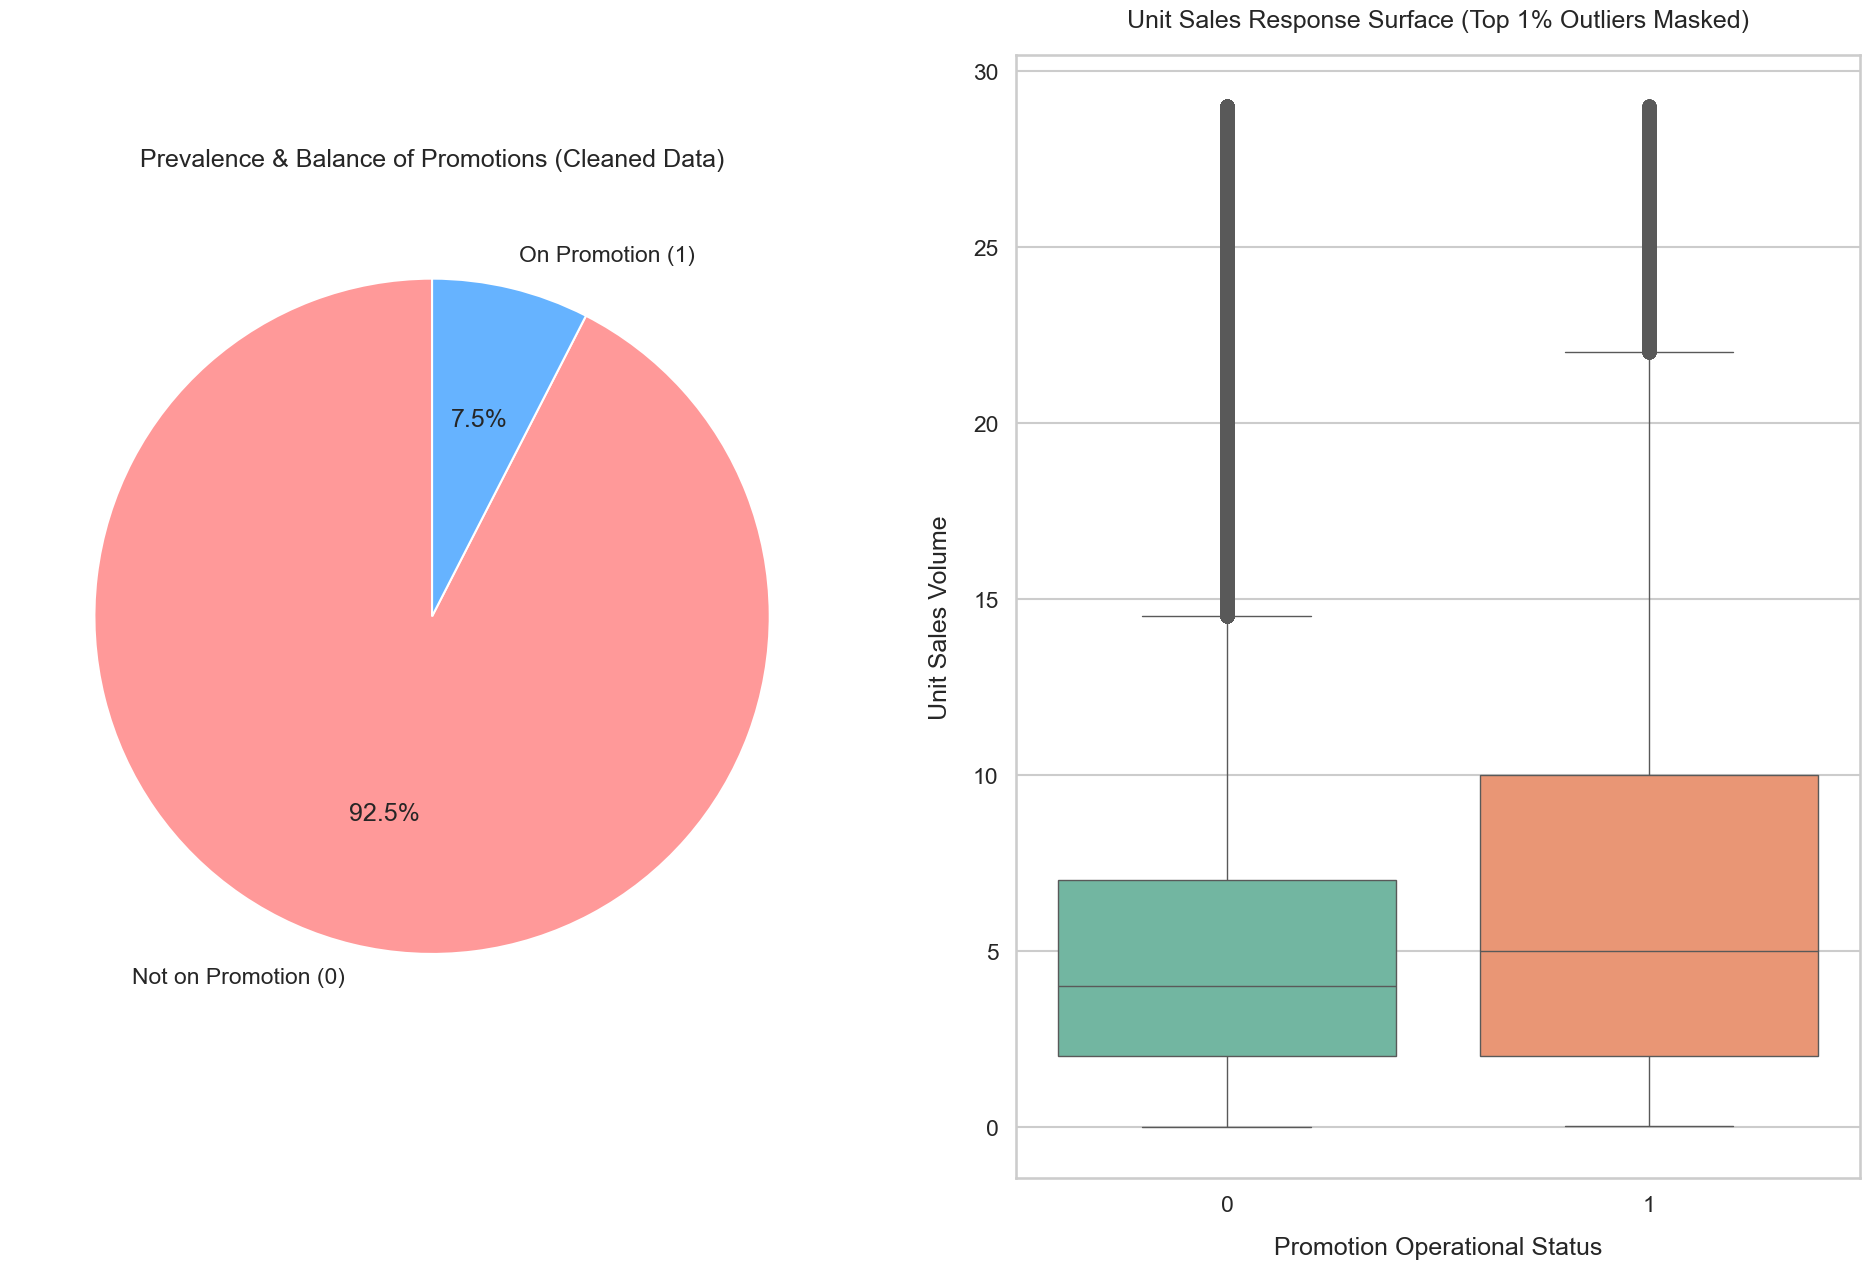

In [41]:
sns.set_theme(style="whitegrid")
sns.set_context("talk", font_scale=1.0) 

raw_sample = pd.read_csv(raw_name, skiprows=lambda i: i > 0 and i % 20 != 0)
raw_sample = raw_sample.dropna(subset=['onpromotion'])
raw_sample['onpromotion'] = raw_sample['onpromotion'].astype(int)

# remove negative sales
raw_sample = raw_sample[raw_sample['unit_sales'] > 0]

fig1, axes1 = plt.subplots(1, 2, figsize=(20, 14))

promo_counts = raw_sample['onpromotion'].value_counts()
axes1[0].pie(promo_counts, labels=['Not on Promotion (0)', 'On Promotion (1)'], 
            autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
axes1[0].set_title('Prevalence & Balance of Promotions (Cleaned Data)', pad=20)

q_high = raw_sample['unit_sales'].quantile(0.95)
trimmed_sample = raw_sample[raw_sample['unit_sales'] < q_high]

sns.boxplot(data=trimmed_sample, x='onpromotion', y='unit_sales', ax=axes1[1], palette='Set2')
axes1[1].set_title('Unit Sales Response Surface (Top 1% Outliers Masked)', pad=20)
axes1[1].set_xlabel('Promotion Operational Status', labelpad=15)
axes1[1].set_ylabel('Unit Sales Volume', labelpad=15)

plt.tight_layout(pad=3.0)
plt.show()

### Aggregated Data

/var/folders/fx/7bytz06n0jq4xyt3__z9ymwr0000gn/T/ipykernel_56459/1535838288.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_agg, x='Granularity', y='sales', ax=axes2[0], palette='pastel')
/var/folders/fx/7bytz06n0jq4xyt3__z9ymwr0000gn/T/ipykernel_56459/1535838288.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_agg, x='Granularity', y='promotion', ax=axes2[1], palette='pastel')


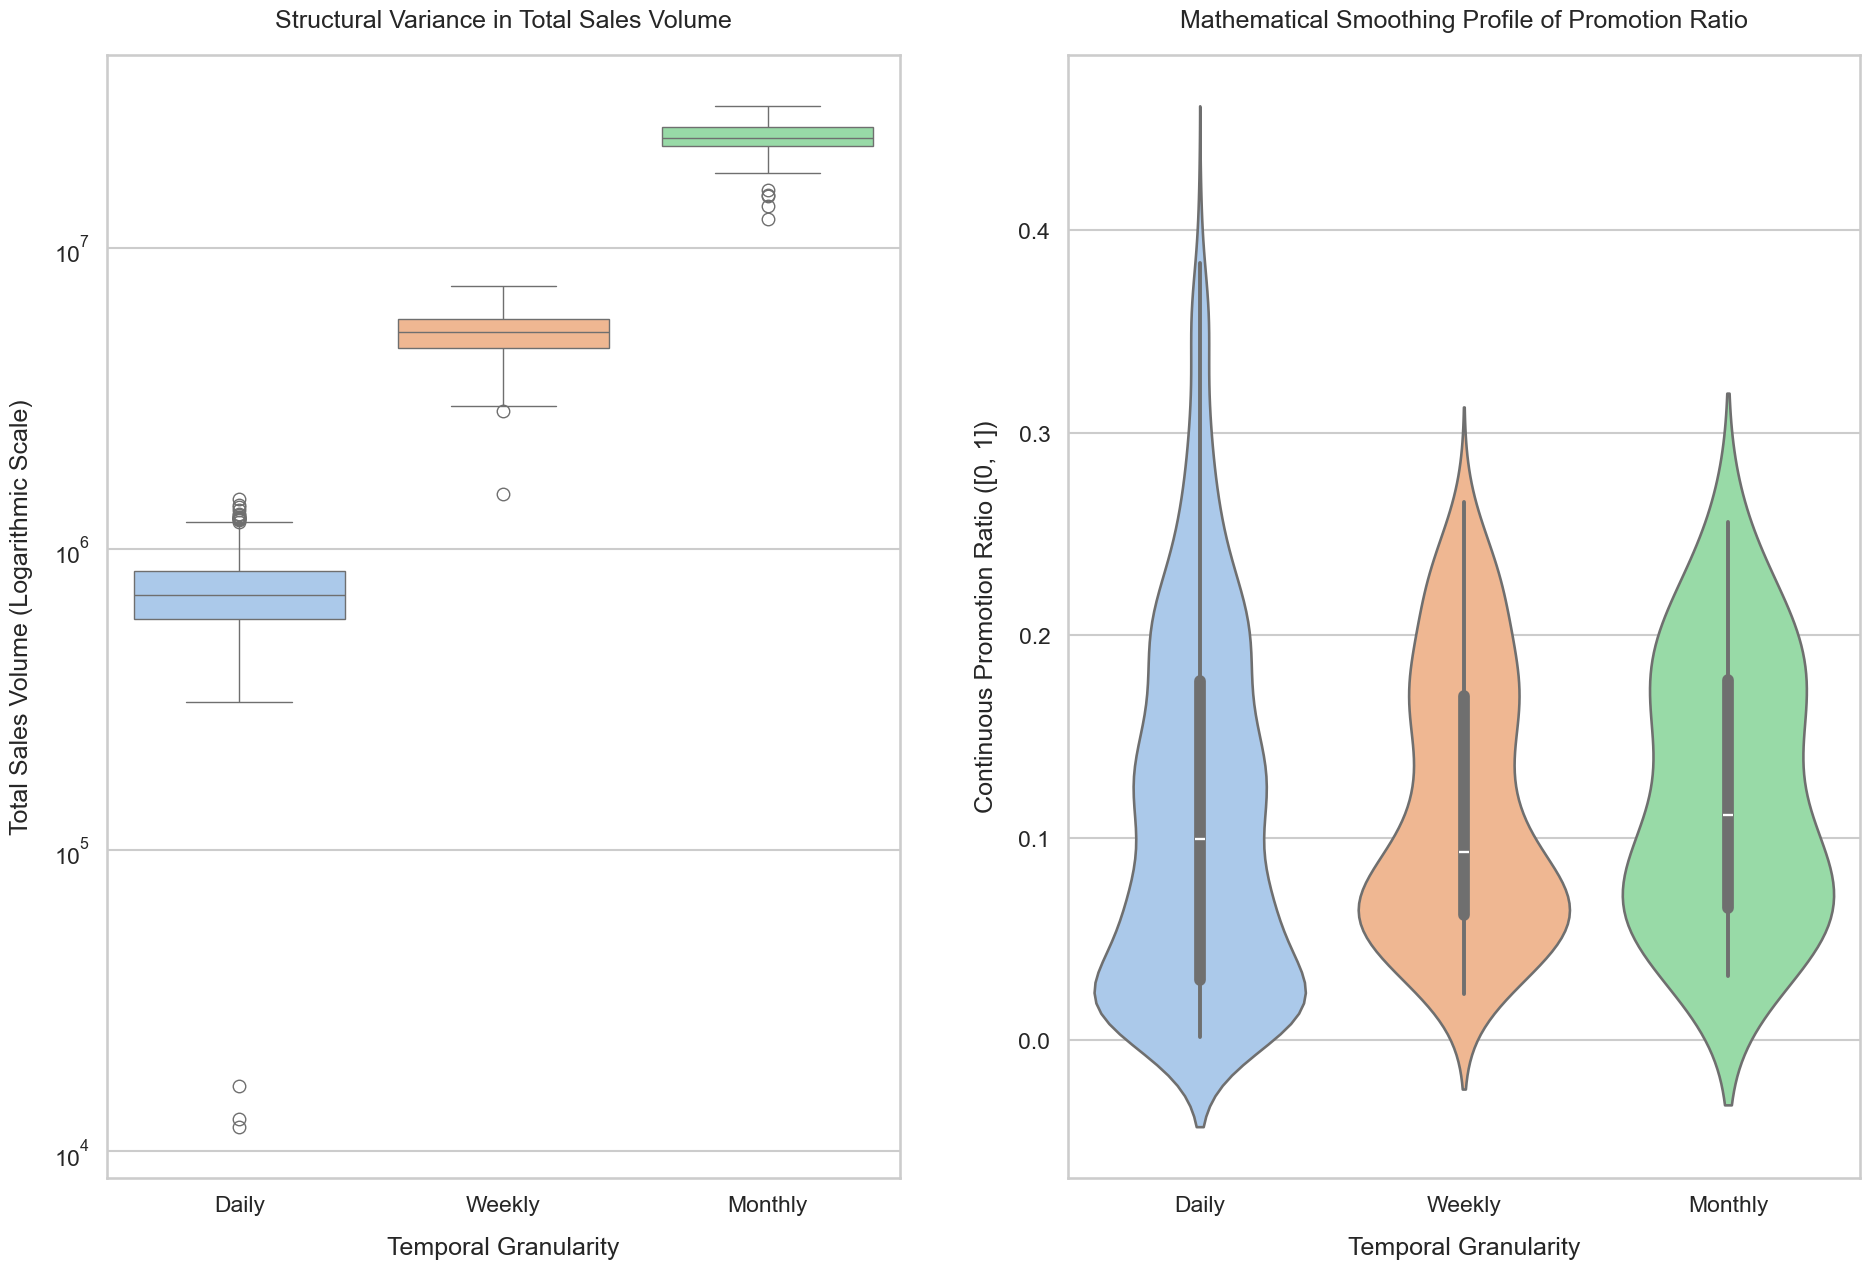

In [42]:
daily['Granularity'] = 'Daily'
weekly['Granularity'] = 'Weekly'
monthly['Granularity'] = 'Monthly'
combined_agg = pd.concat([daily, weekly, monthly], ignore_index=True)

fig2, axes2 = plt.subplots(1, 2, figsize=(20, 14))

sns.boxplot(data=combined_agg, x='Granularity', y='sales', ax=axes2[0], palette='pastel')
axes2[0].set_title('Structural Variance in Total Sales Volume', pad=20)
axes2[0].set_yscale('log')
axes2[0].set_ylabel('Total Sales Volume (Logarithmic Scale)', labelpad=15)
axes2[0].set_xlabel('Temporal Granularity', labelpad=15)

sns.violinplot(data=combined_agg, x='Granularity', y='promotion', ax=axes2[1], palette='pastel')
axes2[1].set_title('Mathematical Smoothing Profile of Promotion Ratio', pad=20)
axes2[1].set_ylabel('Continuous Promotion Ratio ([0, 1])', labelpad=15)
axes2[1].set_xlabel('Temporal Granularity', labelpad=15)

plt.tight_layout(pad=3.0)
plt.show()

### Best Models

In [43]:
if 'best_models' not in globals():
    print("'best_models' has not been created; make sure to run the parameter tuning.")
else:
    df = pd.json_normalize(best_models).drop(columns=["best_model"])

    df.columns = [col.replace("best_params.", "param_") for col in df.columns]

    # Reorder columns for readability
    preferred_order = [
        "model_name",
        "dataset",
        "best_score"
    ]
    param_cols = [c for c in df.columns if c not in preferred_order]
    df = df[preferred_order + param_cols]

    display(df)

,model_name,dataset,best_score,param_learning_rate,param_n_estimators,param_gamma,param_max_depth,param_subsample
0,AdaBoost,daily,8.443008e+04,0.03,100,NaN,NaN,NaN
1,XGBoost,daily,7.440936e+04,0.08,100,0.0,2.0,0.8
2,AdaBoost,weekly,4.912659e+05,0.03,100,NaN,NaN,NaN
3,XGBoost,weekly,4.438821e+05,0.08,100,0.0,3.0,0.8
4,AdaBoost,monthly,2.139214e+06,0.03,100,NaN,NaN,NaN
5,XGBoost,monthly,1.724076e+06,0.08,100,0.0,3.0,1.0


### Evaluation

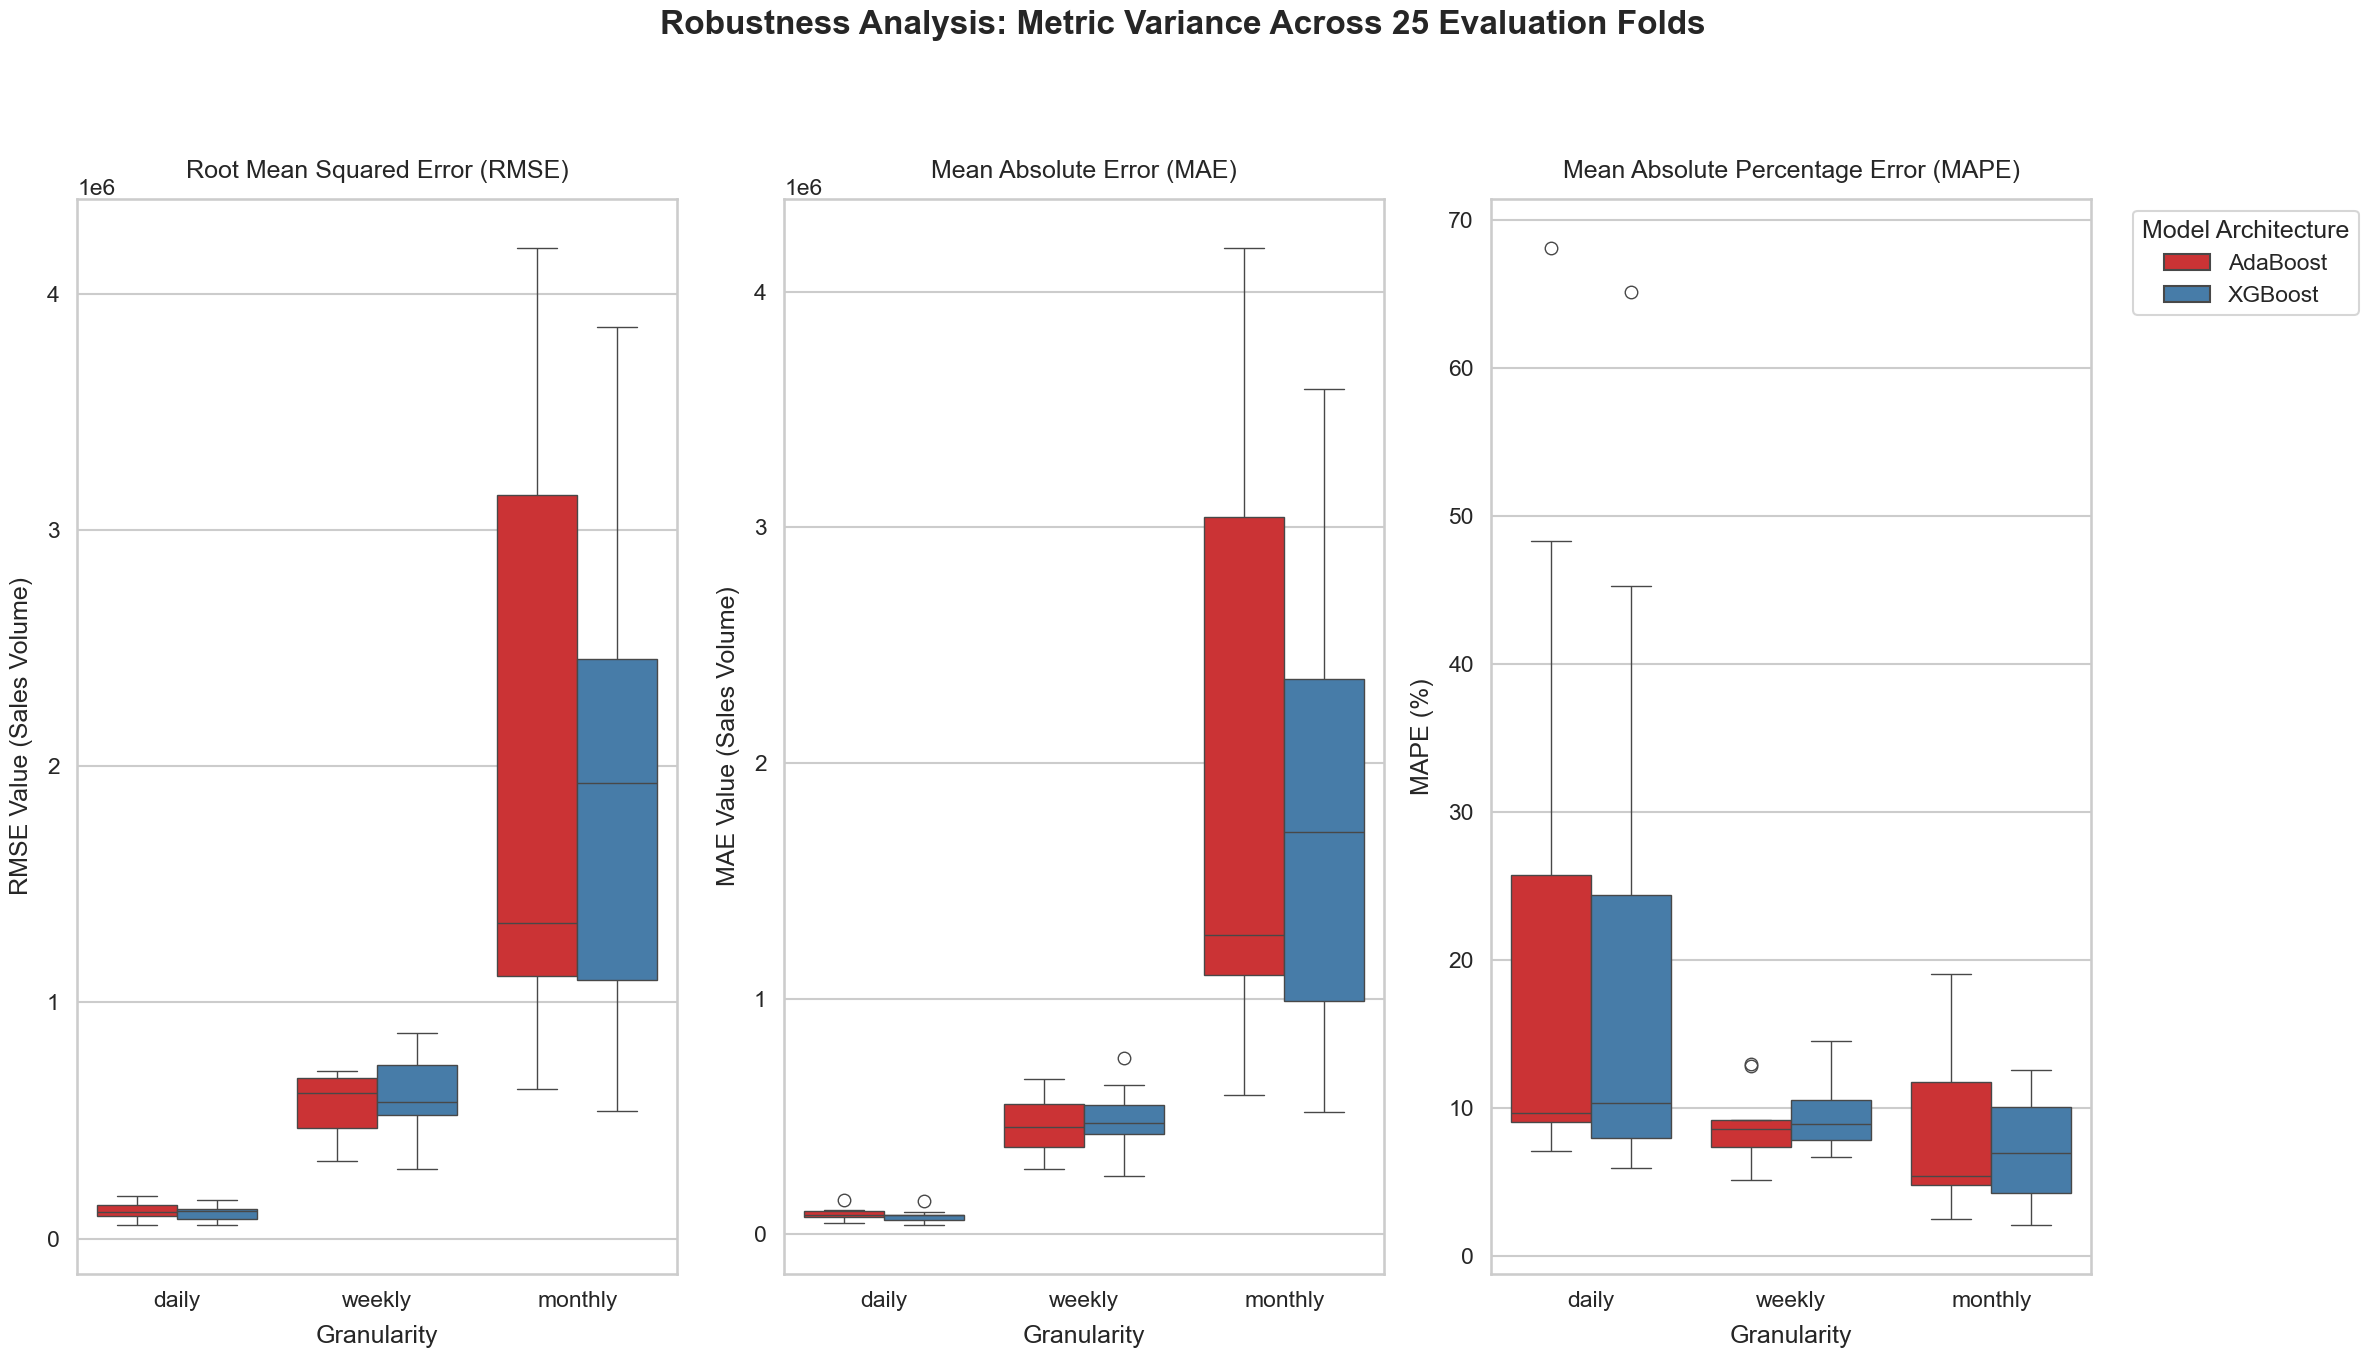

In [44]:
# REGEX BULLDOZER: Safely extract numbers ignoring Pandas string formatting quirks
def extract_scores(val):
    if isinstance(val, list): return val
    return [float(x) for x in re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(val))]

for col in ['rmse_scores', 'mae_scores', 'mape_scores']:
    results[col] = results[col].apply(extract_scores)

fig3, axes3 = plt.subplots(1, 3, figsize=(24, 13))

# Panel 1: RMSE (exploded independently to bypass pd errors)
rmse_df = results[['dataset', 'model_name', 'rmse_scores']].explode('rmse_scores')
rmse_df['rmse_scores'] = rmse_df['rmse_scores'].astype(float)
sns.boxplot(data=rmse_df, x='dataset', y='rmse_scores', hue='model_name', ax=axes3[0], palette='Set1')
axes3[0].set_title('Root Mean Squared Error (RMSE)', pad=15)
axes3[0].set_ylabel('RMSE Value (Sales Volume)', labelpad=10)
axes3[0].set_xlabel('Granularity', labelpad=10)

# Panel 2: MAE (exploded independently)
mae_df = results[['dataset', 'model_name', 'mae_scores']].explode('mae_scores')
mae_df['mae_scores'] = mae_df['mae_scores'].astype(float)
sns.boxplot(data=mae_df, x='dataset', y='mae_scores', hue='model_name', ax=axes3[1], palette='Set1')
axes3[1].set_title('Mean Absolute Error (MAE)', pad=15)
axes3[1].set_ylabel('MAE Value (Sales Volume)', labelpad=10)
axes3[1].set_xlabel('Granularity', labelpad=10)

# Panel 3: MAPE (exploded independently)
mape_df = results[['dataset', 'model_name', 'mape_scores']].explode('mape_scores')
mape_df['mape_scores'] = mape_df['mape_scores'].astype(float)
sns.boxplot(data=mape_df, x='dataset', y='mape_scores', hue='model_name', ax=axes3[2], palette='Set1')
axes3[2].set_title('Mean Absolute Percentage Error (MAPE)', pad=15)
axes3[2].set_ylabel('MAPE (%)', labelpad=10)
axes3[2].set_xlabel('Granularity', labelpad=10)

# clean up legends
axes3[0].legend_.remove()
axes3[1].legend_.remove()
axes3[2].legend(title='Model Architecture', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Robustness Analysis: Metric Variance Across 25 Evaluation Folds', y=1.05, fontsize=24, fontweight='bold')
plt.tight_layout()
plt.show()

### Tuning

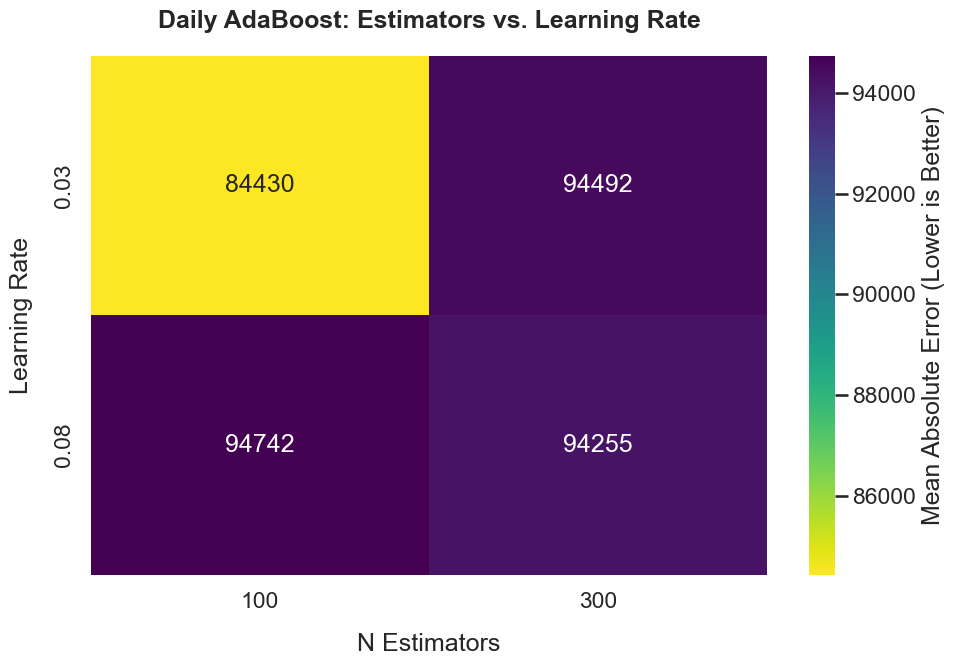

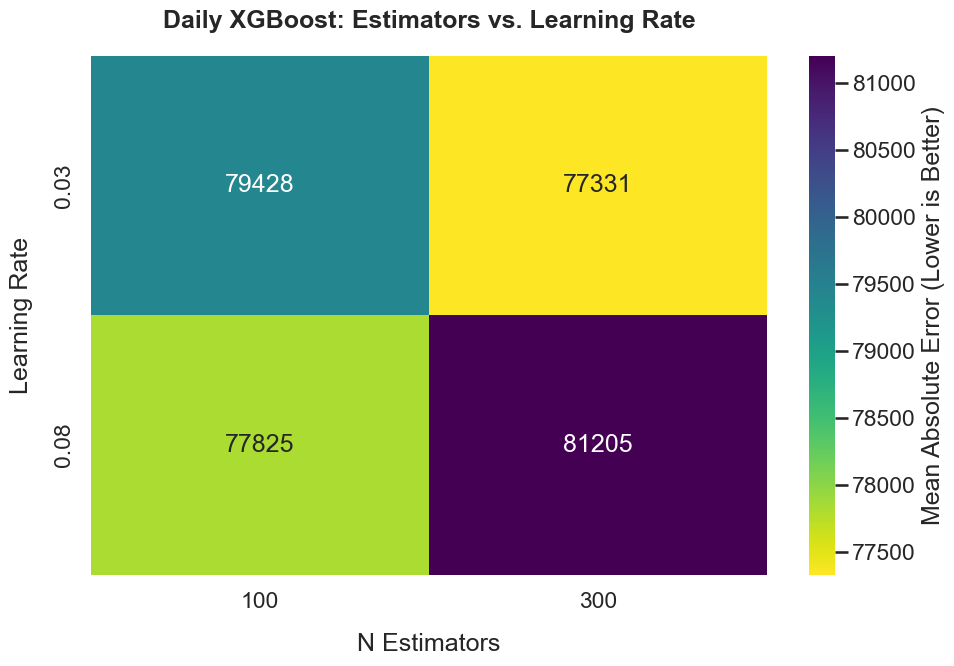

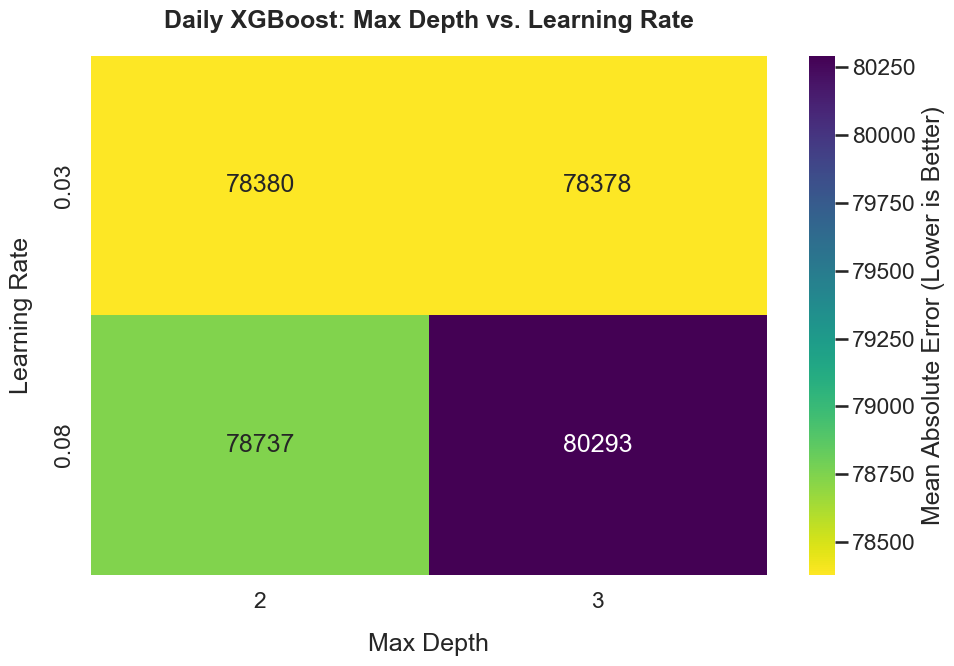

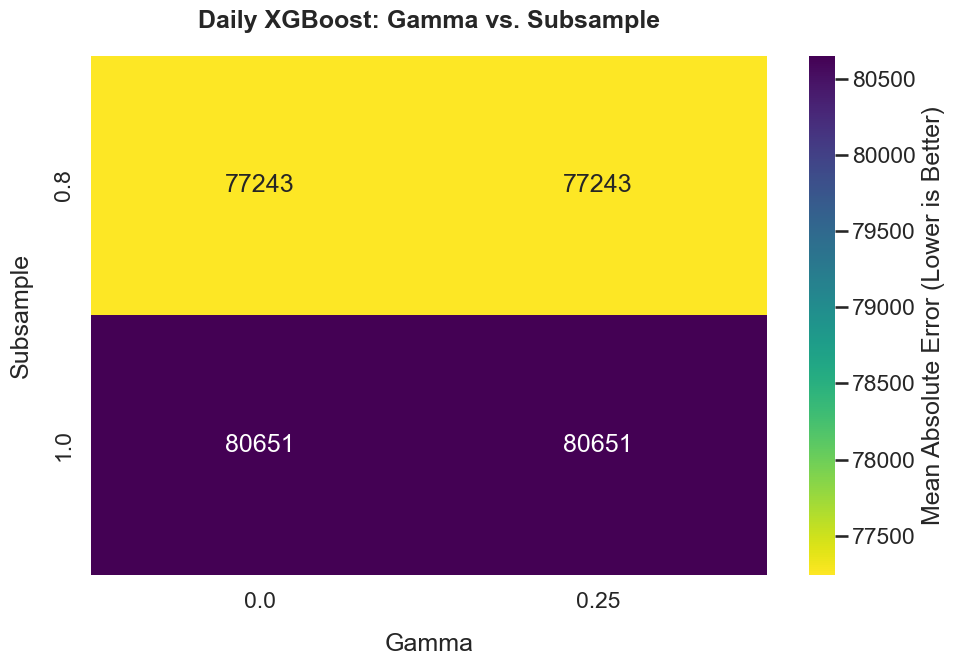

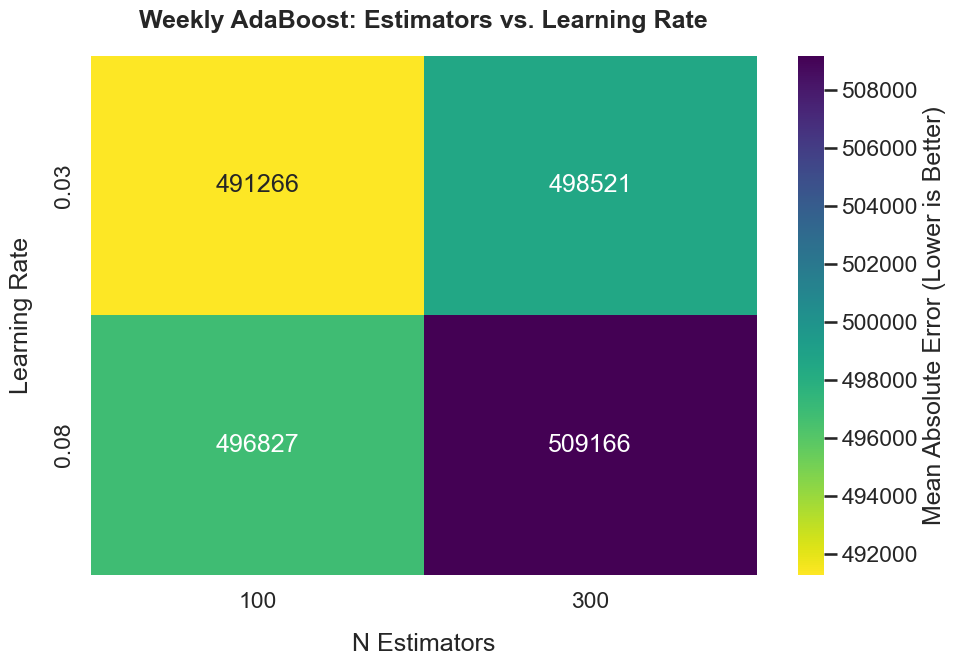

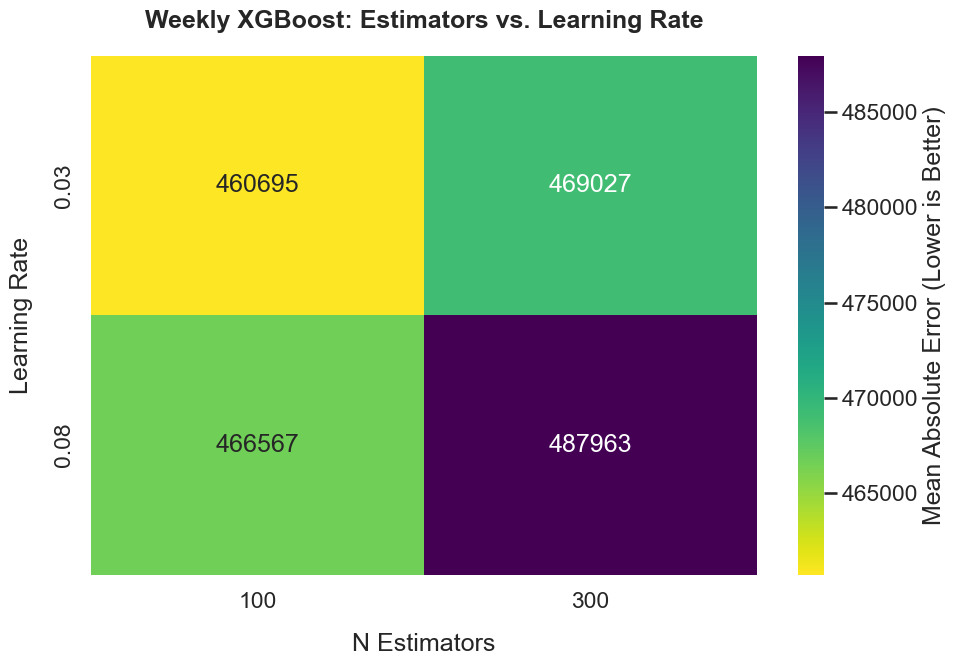

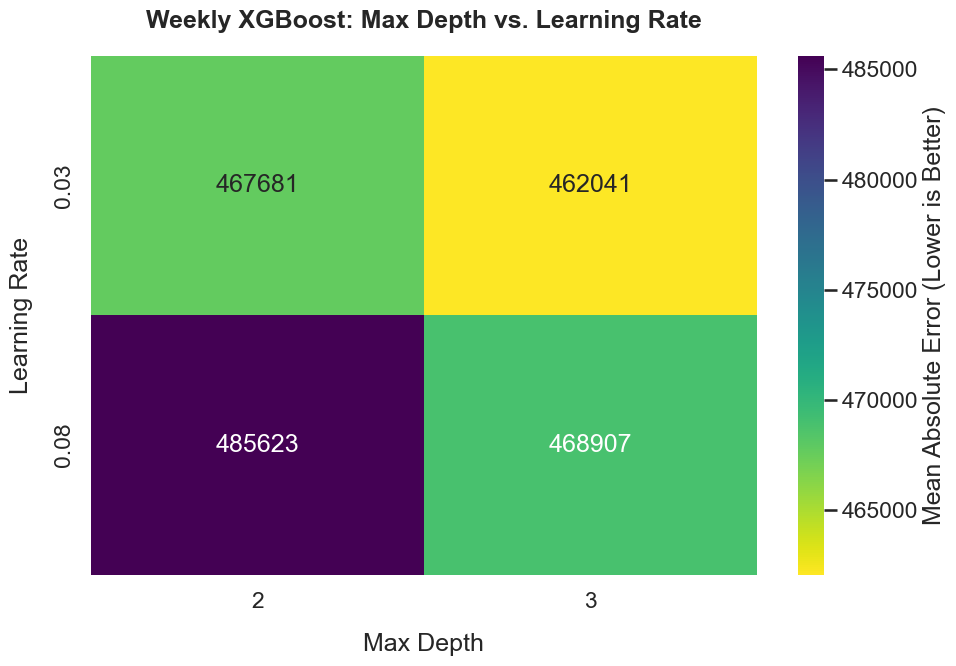

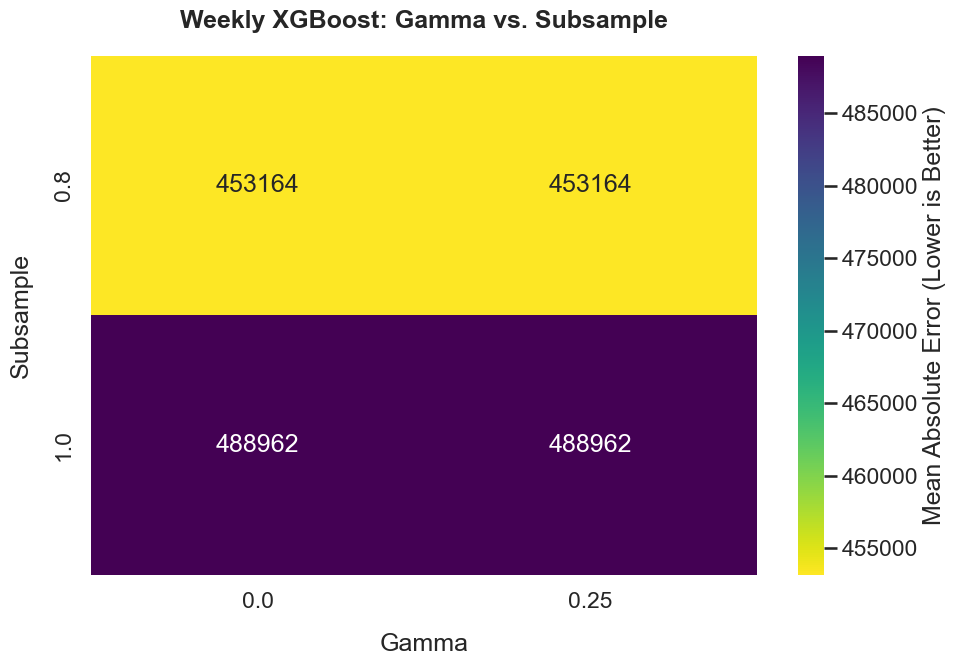

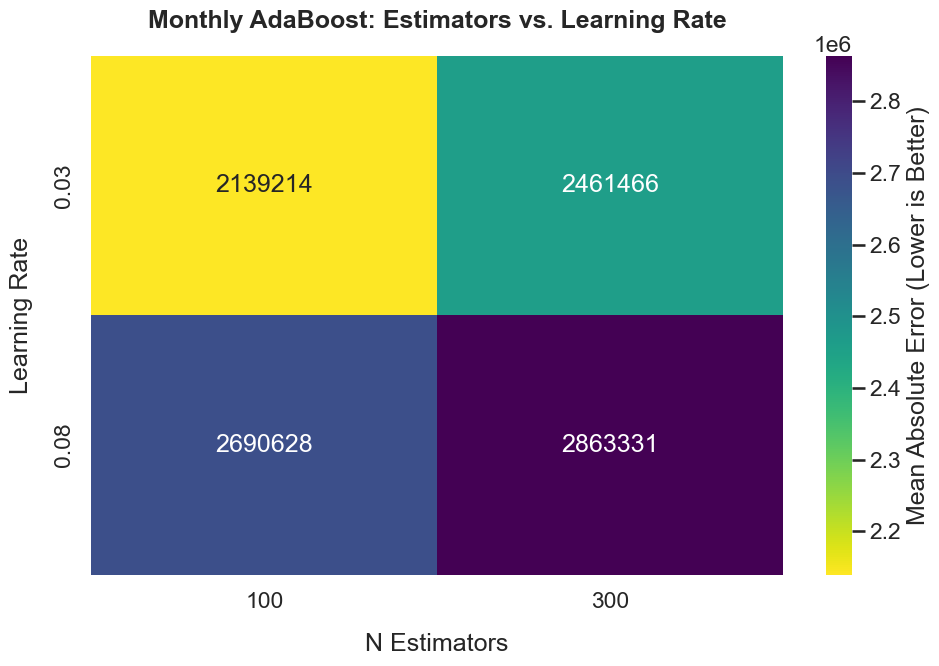

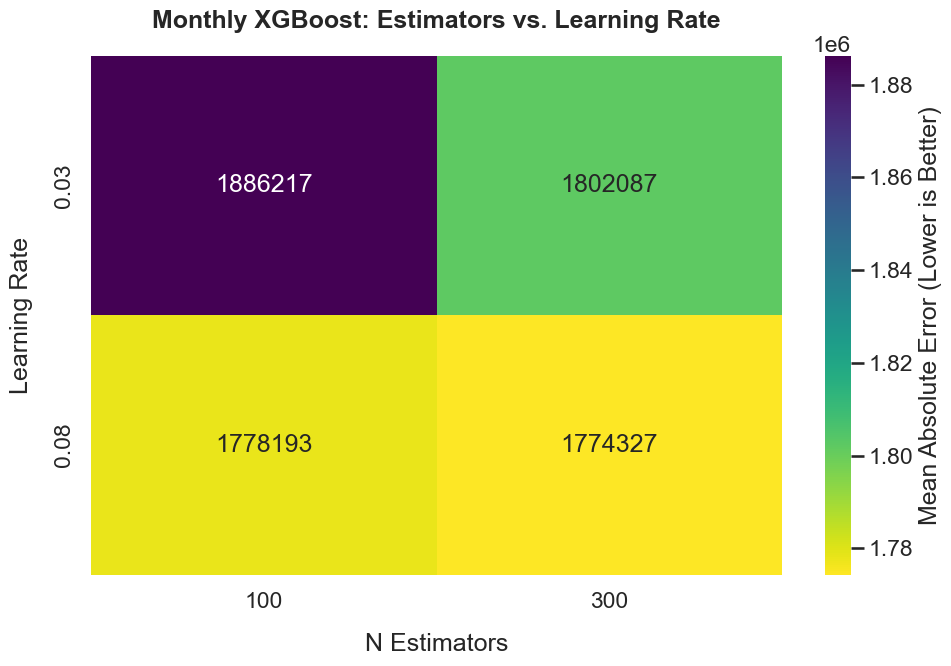

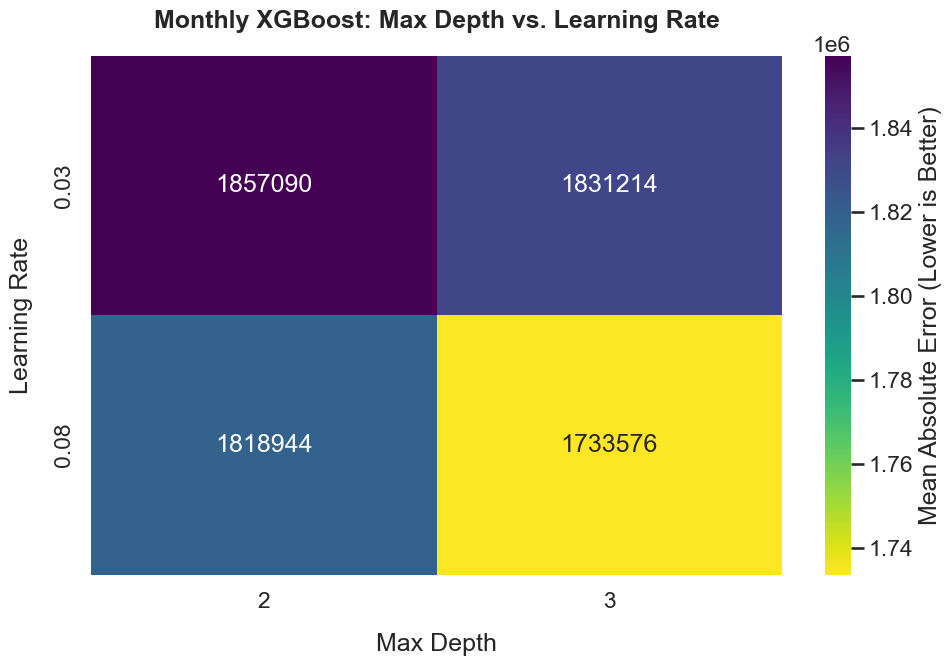

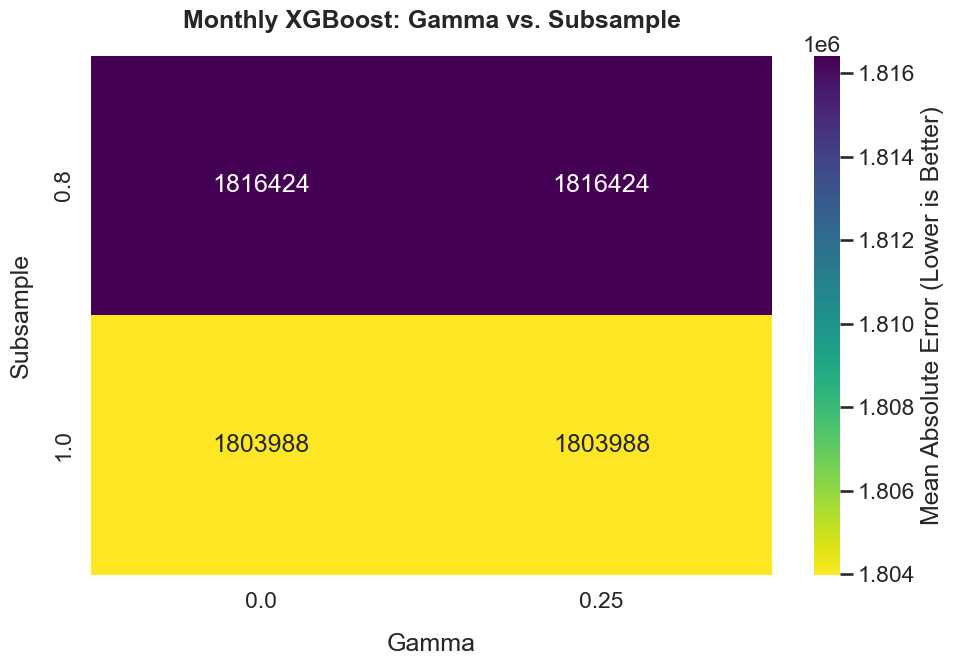

In [45]:
def plot_hyperparameter_heatmap(grid_search_obj, param_x, param_y, title):
    cv_results = pd.DataFrame(grid_search_obj.cv_results_)
    cv_results["mean_test_score"] = cv_results["mean_test_score"] * -1

    pivot_table = cv_results.pivot_table(
        values="mean_test_score", 
        index=param_y, 
        columns=param_x,
        aggfunc="mean"
    )

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        pivot_table,
        annot=True,
        fmt=".0f",
        cmap="viridis_r", 
        cbar_kws={"label": "Mean Absolute Error (Lower is Better)"}
    )

    plt.title(title, pad=20, fontweight="bold")
    plt.xlabel(param_x.replace("param_", "").replace("_", " ").title(), labelpad=15)
    plt.ylabel(param_y.replace("param_", "").replace("_", " ").title(), labelpad=15)

    plt.tight_layout()
    plt.show()

if "search_objects" not in globals():
    print("Search objects are missing because tuning was skipped or the kernel was restarted.")
    print("Set force_rerun=True and run the notebook from the top to regenerate the heatmaps.")
else:
    for dataset_name in ["daily", "weekly", "monthly"]:
        ada_search = search_objects[(dataset_name, "AdaBoost")]
        xgb_search = search_objects[(dataset_name, "XGBoost")]

        plot_hyperparameter_heatmap(
            ada_search,
            "param_n_estimators",
            "param_learning_rate",
            f"{dataset_name.title()} AdaBoost: Estimators vs. Learning Rate"
        )

        plot_hyperparameter_heatmap(
            xgb_search,
            "param_n_estimators",
            "param_learning_rate",
            f"{dataset_name.title()} XGBoost: Estimators vs. Learning Rate"
        )

        plot_hyperparameter_heatmap(
            xgb_search,
            "param_max_depth",
            "param_learning_rate",
            f"{dataset_name.title()} XGBoost: Max Depth vs. Learning Rate"
        )

        plot_hyperparameter_heatmap(
            xgb_search,
            "param_gamma",
            "param_subsample",
            f"{dataset_name.title()} XGBoost: Gamma vs. Subsample"
        )

### Statistical tests

In [46]:
# ==============================================================================
# DIAGNOSTIC SUB-BLOCK: DUAL FRIEDMAN TESTS (GRANULARITY IMPACT PER MODEL)
# ==============================================================================
import pandas as pd
import ast
import re
from scipy.stats import friedmanchisquare

print("\n--- STATISTICAL SIGNIFICANCE: GRANULARITY IMPACT ON MAPE ---")

try:
    results = pd.read_csv("results.csv")

    # Safely extract the lists of scores
    def extract_scores(val):
        if isinstance(val, list): return val
        return [float(x) for x in re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(val))]

    results['mape_scores'] = results['mape_scores'].apply(extract_scores)

    # Loop through both models to run independent tests
    for target_model in ['AdaBoost', 'XGBoost']:
        print(f"\n[ Evaluating {target_model.upper()} Architecture ]")
        model_data = results[results['model_name'] == target_model]
        
        daily_mape = model_data[model_data['dataset'] == 'daily']['mape_scores'].values[0]
        weekly_mape = model_data[model_data['dataset'] == 'weekly']['mape_scores'].values[0]
        monthly_mape = model_data[model_data['dataset'] == 'monthly']['mape_scores'].values[0]
        
        # Run the test
        stat, p_value = friedmanchisquare(daily_mape, weekly_mape, monthly_mape)
        
        print(f"Friedman Test Statistic: {stat:.4f}")
        print(f"P-Value: {p_value:.6e}")
        
        if p_value < 0.05:
            print(f"CONCLUSION: Statistically SIGNIFICANT difference in {target_model} accuracy across granularities.")
        else:
            print(f"CONCLUSION: NO significant difference found for {target_model}.")

    print("\n" + "-" * 60)

except IndexError:
    print("[ERROR] Could not extract the scores. Check dataset and model names.")
except Exception as e:
    print(f"[ERROR] {e}")


--- STATISTICAL SIGNIFICANCE: GRANULARITY IMPACT ON MAPE ---

[ Evaluating ADABOOST Architecture ]
Friedman Test Statistic: 8.6000
P-Value: 1.356856e-02
CONCLUSION: Statistically SIGNIFICANT difference in AdaBoost accuracy across granularities.

[ Evaluating XGBOOST Architecture ]
Friedman Test Statistic: 3.2000
P-Value: 2.018965e-01
CONCLUSION: NO significant difference found for XGBoost.

------------------------------------------------------------


In [47]:
# ==============================================================================
# DIAGNOSTIC SUB-BLOCK: FRIEDMAN WITH CONDITIONAL POST-HOC ANALYSIS
# ==============================================================================
import pandas as pd
import re
from scipy.stats import friedmanchisquare, wilcoxon

print("\n--- STATISTICAL SIGNIFICANCE & POST-HOC ANALYSIS ---")

try:
    results = pd.read_csv("results.csv")

    # Safely extract the lists of scores
    def extract_scores(val):
        if isinstance(val, list): return val
        return [float(x) for x in re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(val))]

    results['mape_scores'] = results['mape_scores'].apply(extract_scores)
    
    # Bonferroni correction for 3 pairwise comparisons
    adjusted_alpha = 0.05 / 3  

    # Loop through both models to run independent tests
    for target_model in ['AdaBoost', 'XGBoost']:
        print(f"\n==================================================")
        print(f"[ Evaluating {target_model.upper()} Architecture ]")
        print(f"==================================================")
        
        model_data = results[results['model_name'] == target_model]
        
        daily_mape = model_data[model_data['dataset'] == 'daily']['mape_scores'].values[0]
        weekly_mape = model_data[model_data['dataset'] == 'weekly']['mape_scores'].values[0]
        monthly_mape = model_data[model_data['dataset'] == 'monthly']['mape_scores'].values[0]
        
        # 1. The Omnibus Test (The Alarm)
        stat, p_value = friedmanchisquare(daily_mape, weekly_mape, monthly_mape)
        print(f"Friedman Test Statistic: {stat:.4f} | P-Value: {p_value:.6e}")
        
        # 2. The Conditional Post-Hoc Investigation
        if p_value < 0.05:
            print("Omnibus Result: SIGNIFICANT. Initiating Post-Hoc Analysis...\n")
            
            # Pairwise Wilcoxon Signed-Rank Tests
            stat_dw, p_dw = wilcoxon(daily_mape, weekly_mape)
            stat_wm, p_wm = wilcoxon(weekly_mape, monthly_mape)
            stat_dm, p_dm = wilcoxon(daily_mape, monthly_mape)

            print(f"  -> Daily vs. Weekly   | P-Value: {p_dw:.6e} | Significant? {'YES' if p_dw < adjusted_alpha else 'NO'}")
            print(f"  -> Weekly vs. Monthly | P-Value: {p_wm:.6e} | Significant? {'YES' if p_wm < adjusted_alpha else 'NO'}")
            print(f"  -> Daily vs. Monthly  | P-Value: {p_dm:.6e} | Significant? {'YES' if p_dm < adjusted_alpha else 'NO'}")
            print(f"     (Significance threshold tightly controlled at a = {adjusted_alpha:.4f})")
            
        else:
            print("Omnibus Result: NOT SIGNIFICANT.")
            print("No structural variance detected. Post-hoc analysis is statistically invalid and has been bypassed.")

    print("\n" + "=" * 50)

except IndexError:
    print("[ERROR] Could not extract the scores. Check dataset and model names.")
except Exception as e:
    print(f"[ERROR] {e}")


--- STATISTICAL SIGNIFICANCE & POST-HOC ANALYSIS ---

[ Evaluating ADABOOST Architecture ]
Friedman Test Statistic: 8.6000 | P-Value: 1.356856e-02
Omnibus Result: SIGNIFICANT. Initiating Post-Hoc Analysis...

  -> Daily vs. Weekly   | P-Value: 2.182428e-02 | Significant? NO
  -> Weekly vs. Monthly | P-Value: 3.328798e-01 | Significant? NO
  -> Daily vs. Monthly  | P-Value: 2.841686e-02 | Significant? NO
     (Significance threshold tightly controlled at a = 0.0167)

[ Evaluating XGBOOST Architecture ]
Friedman Test Statistic: 3.2000 | P-Value: 2.018965e-01
Omnibus Result: NOT SIGNIFICANT.
No structural variance detected. Post-hoc analysis is statistically invalid and has been bypassed.

